# Setup

## Libraries

In [1]:
import re
import pandas as pd
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import itertools
import tracemalloc
import time
from collections import Counter
import matplotlib.ticker as ticker
import random
import statistics
from memory_profiler import memory_usage
from math import comb
import re
import pandas as pd
from pathlib import Path
import zipfile
from collections import defaultdict
from itertools import combinations
import pandas as pd
import numpy as np
from itertools import combinations
import math
import random
from collections import defaultdict
from typing import Iterable
import itertools
from concurrent.futures import ProcessPoolExecutor


/Users/bercaakbayir/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Helper Functions

In [2]:
def kaggle_data_handler(kaggle_url, csv_index=0):
    match = re.search(r"kaggle\.com/datasets/([^/]+)/([^/?#]+)", kaggle_url)
    if not match:
        raise ValueError(f"Could not parse Kaggle dataset URL: {kaggle_url}")

    owner, slug = match.group(1), match.group(2)

    try:
        download_dir = Path(__file__).parent.parent / "data"
    except NameError:
        download_dir = Path.cwd() / "data"

    existing_csvs = sorted(download_dir.glob("*.csv")) if download_dir.exists() else []

    if not existing_csvs:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        download_dir.mkdir(parents=True, exist_ok=True)
        api.dataset_download_files(f"{owner}/{slug}", path=str(download_dir), unzip=False, quiet=False)

        for z in download_dir.glob("*.zip"):
            with zipfile.ZipFile(z, "r") as zf:
                zf.extractall(download_dir)
            z.unlink()

        existing_csvs = sorted(download_dir.glob("*.csv"))

    return pd.read_csv(existing_csvs[csv_index])

In [3]:
def print_results(result: dict, top_n: int = 20) -> None:
    fi      = result["frequent_itemsets"]
    cands   = result["candidates"]
    fp      = result["false_positives"]
    counts  = result["global_counts"]

    print("=" * 60)
    print("Results")
    print("=" * 60)
    effective = result.get("effective_chunks", result["num_chunks"])
    if effective < result["num_chunks"]:
        print(f"  Chunks used : {effective} (capped from {result['num_chunks']} — support too low)")
    else:
        print(f"  Chunks used : {result['num_chunks']}")
    print(f"  Local support : {result['local_support']}")
    print(f"  Candidate itemsets : {len(cands)}")
    print(f"  False positives : {len(fp)}  (eliminated in pass 2)")
    print(f"  Truly frequent : {len(fi)}")
    print()

    sorted_fi = sorted(fi, key=lambda s: (len(s), -counts.get(s, 0)))
    by_size: dict = defaultdict(list)
    for s in sorted_fi:
        by_size[len(s)].append(s)

    for size in sorted(by_size):
        label = {1: "Singletons", 2: "Pairs", 3: "Triples"}.get(
            size, f"Size-{size} sets"
        )
        items_at_size = sorted(by_size[size], key=lambda s: -counts.get(s, 0))
        print(f"  {label} ({len(items_at_size)} frequent):")
        for itemset in items_at_size[:top_n]:
            cnt = counts.get(itemset, 0)
            items_str = ", ".join(str(x) for x in sorted(itemset))
            print(f"    {{{items_str}}}  [support={cnt}]")
        if len(items_at_size) > top_n:
            print(f"    ... and {len(items_at_size) - top_n} more")
        print()

In [4]:
def support(itemset, baskets) -> float:
    """Fraction of baskets that contain every item in itemset."""
    itemset = frozenset(itemset)
    return sum(1 for b in baskets if itemset.issubset(b)) / len(baskets)



def confidence(lhs, rhs, baskets, verbose=False) -> float | None:
    """P(lhs ∪ rhs) / P(lhs)."""
    lhs, rhs = frozenset(lhs), frozenset(rhs)
    sup_lhs   = sum(1 for b in baskets if lhs.issubset(b))
    sup_union = sum(1 for b in baskets if (lhs | rhs).issubset(b))

    if sup_lhs == 0:
        return None

    conf = sup_union / sup_lhs

    if verbose:
        print(f"  support({set(lhs)})          = {sup_lhs}")
        print(f"  support({set(lhs | rhs)})    = {sup_union}")
        print(f"  confidence({set(lhs)} → {set(rhs)}) "
              f"= {sup_union}/{sup_lhs} = {conf:.4f}")
    return conf



def interest(lhs, rhs, baskets, verbose=False) -> float | None:
    """confidence(lhs → rhs) − P(rhs)."""
    rhs  = frozenset(rhs)
    conf = confidence(lhs, rhs, baskets, verbose=verbose)

    if conf is None:
        return None

    sup_rhs  = sum(1 for b in baskets if rhs.issubset(b))
    prob_rhs = sup_rhs / len(baskets)
    score    = conf - prob_rhs

    if verbose:
        print(f"  P({set(rhs)})"
              f"= {sup_rhs}/{len(baskets)} = {prob_rhs:.4f}")
        print(f"  interest({set(lhs)} → {set(rhs)}) "
              f"= {conf:.4f} - {prob_rhs:.4f} = {score:.4f}")
    return score



def generate_association_rules(
    frequent_itemsets,          
    baskets,                    
    global_counts=None,         
    min_confidence: float = 0.0,
    min_interest:   float | None = None) -> pd.DataFrame:
    
    if isinstance(frequent_itemsets, dict):
        itemsets = set(frequent_itemsets.keys())
    else:
        if global_counts is None:
            raise ValueError(
                "global_counts must be provided when frequent_itemsets is a set"
            )
        itemsets = set(frequent_itemsets)

    n = len(baskets)
    rows = []

    for itemset in itemsets:
        if len(itemset) < 2:
            continue

        # Every single-item consequent derived from this itemset
        for item in itemset:
            rhs = frozenset([item])
            lhs = itemset - rhs

            conf = confidence(lhs, rhs, baskets)
            if conf is None or conf < min_confidence:
                continue

            sup   = support(itemset, baskets)
            score = interest(lhs, rhs, baskets)

            if min_interest is not None and (score is None or score < min_interest):
                continue

            rows.append({
                "antecedents": set(lhs),
                "consequents": set(rhs),
                "support":     round(sup * n),
                "confidence":  round(conf * 100, 2), 
                "interest":    round(score, 4) if score is not None else None,
            })

    df = (
        pd.DataFrame(rows, columns=["antecedents", "consequents",
                                    "support", "confidence", "interest"])
        .sort_values("confidence", ascending=False)
        .reset_index(drop=True)
    )
    return df

## Data Downloading

In [5]:
kaggle_link = 'https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows'

In [6]:
df = kaggle_data_handler(kaggle_link)

In [7]:
df

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000"
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN


In [8]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [10]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [11]:
df[['Series_Title', 'Star1', 'Star2', 'Star3', 'Star4']]

,Series_Title,Star1,Star2,Star3,Star4
0,The Shawshank Redemption,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,The Godfather,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,The Dark Knight,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,The Godfather: Part II,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,12 Angry Men,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler
...,...,...,...,...,...
995,Breakfast at Tiffany's,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen
996,Giant,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker
997,From Here to Eternity,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed
998,Lifeboat,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix


# Basket Data Analysis

In [12]:
null_pct = df.isnull().sum() / len(df) * 100

blank_pct = df.apply(lambda col: col.astype(str).str.strip().eq('').sum() / len(df) * 100)

pd.DataFrame({'null_%': null_pct, 'blank_%': blank_pct}).round(2)

,null_%,blank_%
Poster_Link,0.0,0.0
Series_Title,0.0,0.0
Released_Year,0.0,0.0
Certificate,10.1,0.0
Runtime,0.0,0.0
Genre,0.0,0.0
IMDB_Rating,0.0,0.0
Overview,0.0,0.0
Meta_score,15.7,0.0
Director,0.0,0.0


In [13]:
def normalize_name(name: str) -> str:
    name = name.strip()
    name = re.sub(r'\s+', ' ', name)         
    name = name.title()                       
    name = re.sub(r"'([A-Z])", lambda m: "'" + m.group(1), name)
    return name


def normalize_baskets(baskets: list[set]) -> list[set]:
    return [
        {normalize_name(actor) for actor in basket}
        for basket in baskets
    ]

In [14]:
actor_cols = ['Star1', 'Star2', 'Star3', 'Star4']
df[actor_cols] = df[actor_cols].map(
    lambda x: normalize_name(x) if pd.notna(x) else x
)

In [15]:
def sample_baskets(df, proportion, seed=42):
    basket_def = df[["Star1","Star2","Star3","Star4"]].values.tolist()
    
    clean_baskets = []
    duplicate_count = 0
    for i, row in enumerate(basket_def):
        unique_actors = list(dict.fromkeys(a for a in row if pd.notna(a)))  # preserve order, drop NaN
        if len(unique_actors) < len([a for a in row if pd.notna(a)]):
            duplicate_count += 1
            print(f"  [WARNING] Movie index {i} has duplicate actors: {row}")
        clean_baskets.append(set(unique_actors))
    
    if duplicate_count == 0:
        print("[OK] No duplicate actors found within any movie.")
    else:
        print(f"\n[WARNING] {duplicate_count} movie(s) had duplicate actors — duplicates removed.")

    sample_size = int(len(clean_baskets) * proportion)
    rng = random.Random(seed)
    sampled_baskets = rng.sample(clean_baskets, sample_size)
    return sampled_baskets

In [16]:
PROPORTION = 1.0 
SUPPORT_LEVEL = 5

In [17]:
baskets = sample_baskets(df, PROPORTION)
print(f"Basket count: {len(baskets)}")

  [WARNING] Movie index 120 has duplicate actors: ['Gene Kelly', 'Gene Kelly', "Donald O'Connor", 'Debbie Reynolds']
  [WARNING] Movie index 320 has duplicate actors: ['Buster Keaton', 'Buster Keaton', 'Marion Mack', 'Glen Cavender']
  [WARNING] Movie index 727 has duplicate actors: ['Taika Waititi', 'Jemaine Clement', 'Taika Waititi', 'Cori Gonzalez-Macuer']
  [WARNING] Movie index 815 has duplicate actors: ['Massimo Troisi', 'Massimo Troisi', 'Philippe Noiret', 'Maria Grazia Cucinotta']

[WARNING] 4 movie(s) had duplicate actors — duplicates removed.
Basket count: 1000


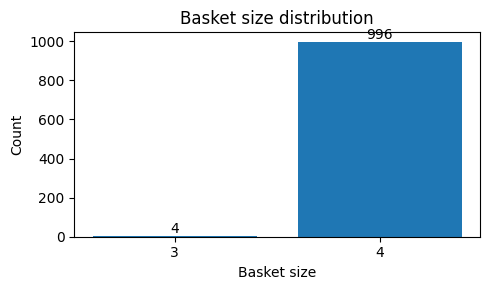

3:4, 4:996


In [18]:
sizes = [len(b) for b in baskets]
counts = Counter(sizes)
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(counts.keys(), counts.values())
ax.bar_label(bars) 
ax.set_xlabel('Basket size')
ax.set_ylabel('Count')
ax.set_title('Basket size distribution')
ax.set_xticks(list(counts.keys()))
plt.tight_layout()
plt.show()

print(', '.join(f'{k}:{v}' for k, v in sorted(counts.items())))

In [19]:
df[df.apply(lambda row: len(set([row['Star1'], row['Star2'], row['Star3'], row['Star4']])) < 4, axis=1)][['Star1','Star2','Star3','Star4', 'Series_Title']]


,Star1,Star2,Star3,Star4,Series_Title
120,Gene Kelly,Gene Kelly,Donald O'Connor,Debbie Reynolds,Singin' in the Rain
320,Buster Keaton,Buster Keaton,Marion Mack,Glen Cavender,The General
727,Taika Waititi,Jemaine Clement,Taika Waititi,Cori Gonzalez-Macuer,What We Do in the Shadows
815,Massimo Troisi,Massimo Troisi,Philippe Noiret,Maria Grazia Cucinotta,Il postino


In [20]:
print(f"There are {df['Director'].nunique()} unique directors in top 1000 movies.")

There are 548 unique directors in top 1000 movies.


In [21]:
all_actors  = pd.concat([df['Star1'], df['Star2'], df['Star3'], df['Star4']])
actor_freq  = all_actors.value_counts()

In [22]:
observed_pairs = set()
for _, row in df[['Star1', 'Star2', 'Star3', 'Star4']].iterrows():
    actors = [a for a in row if pd.notna(a)]
    for pair in combinations(sorted(actors), 2):
        observed_pairs.add(pair)

N_actors      = actor_freq.shape[0]          
N_possible    = comb(N_actors, 2)            
N_observed    = len(observed_pairs)
sparsity      = 1 - (N_observed / N_possible)
coverage      = N_observed / N_possible

In [23]:
print("── Sparsity / Coverage ──")
print(f"Unique actors (N)             : {N_actors}")
print(f"Possible pairs  C(N,2)        : {N_possible:,}")
print(f"Observed co-occurring pairs   : {N_observed:,}")
print(f"Coverage                      : {coverage * 100:.4f}%")
print(f"Sparsity                      : {sparsity * 100:.4f}%")

── Sparsity / Coverage ──
Unique actors (N)             : 2709
Possible pairs  C(N,2)        : 3,667,986
Observed co-occurring pairs   : 5,837
Coverage                      : 0.1591%
Sparsity                      : 99.8409%


In [24]:
pairs_per_movie = df[['Star1', 'Star2', 'Star3', 'Star4']].apply(
    lambda row: len(list(combinations([a for a in row if pd.notna(a)], 2))),
    axis=1
)
print(f"\nPairs per movie (always 4 stars → 6 pairs): {pairs_per_movie.unique().tolist()}")
print(f"Total (movie, pair) observations          : {pairs_per_movie.sum():,}")


Pairs per movie (always 4 stars → 6 pairs): [6]
Total (movie, pair) observations          : 6,000


In [25]:
pair_counts = Counter()
for _, row in df[['Star1', 'Star2', 'Star3', 'Star4']].iterrows():
    actors = [a for a in row if pd.notna(a)]
    for pair in combinations(sorted(actors), 2):
        pair_counts[pair] += 1

In [26]:
print("\n── Top N Movies and Occured Pairs ──")
total_movies = len(df)
for min_count in [2, 3, 4, 5, 6]:
    pct = min_count / total_movies * 100
    qualifying = sum(1 for c in pair_counts.values() if c >= min_count)
    print(f"  count ≥ {min_count} ({pct}%)  →  {qualifying} pairs qualify")



── Top N Movies and Occured Pairs ──
  count ≥ 2 (0.2%)  →  129 pairs qualify
  count ≥ 3 (0.3%)  →  25 pairs qualify
  count ≥ 4 (0.4%)  →  5 pairs qualify
  count ≥ 5 (0.5%)  →  3 pairs qualify
  count ≥ 6 (0.6%)  →  1 pairs qualify


In [27]:
pair_counts = Counter()
for _, row in df[['Star1', 'Star2', 'Star3', 'Star4']].iterrows():
    actors = [a for a in row if pd.notna(a)]
    for pair in combinations(sorted(actors), 2):
        pair_counts[pair] += 1

In [28]:
genre_actors = defaultdict(set)
genre_movie_counts = defaultdict(int)

for _, row in df.iterrows():
    genres = [g.strip() for g in row['Genre'].split(',')]
    actors = [row[c] for c in ['Star1','Star2','Star3','Star4'] if pd.notna(row[c])]
    for genre in genres:
        genre_actors[genre].update(actors)
        genre_movie_counts[genre] += 1

In [29]:
genre_actor_df = (
    pd.DataFrame([
        {
            'Genre'        : genre,
            'Unique_Actors': len(actors),
            'Movie_Count'  : genre_movie_counts[genre],
        }
        for genre, actors in genre_actors.items()
    ])
    .assign(Actors_per_Movie=lambda x: (x['Unique_Actors'] / x['Movie_Count']).round(2))
    .sort_values('Unique_Actors', ascending=False)
    .reset_index(drop=True)
)

In [30]:
print(f"Unique genres found : {len(genre_actor_df)}")
print(f"\nFull Summary (sorted by Unique Actors):")
print(genre_actor_df.to_string(index=False))

Unique genres found : 21

Full Summary (sorted by Unique Actors):
    Genre  Unique_Actors  Movie_Count  Actors_per_Movie
    Drama           2086          724              2.88
   Comedy            775          233              3.33
    Crime            686          209              3.28
Adventure            609          196              3.11
   Action            586          189              3.10
 Thriller            480          137              3.50
  Romance            449          125              3.59
Biography            379          109              3.48
  Mystery            357           99              3.61
Animation            301           82              3.67
  Fantasy            234           66              3.55
   Sci-Fi            231           67              3.45
  History            215           56              3.84
   Family            208           56              3.71
      War            196           51              3.84
    Music            139           35 

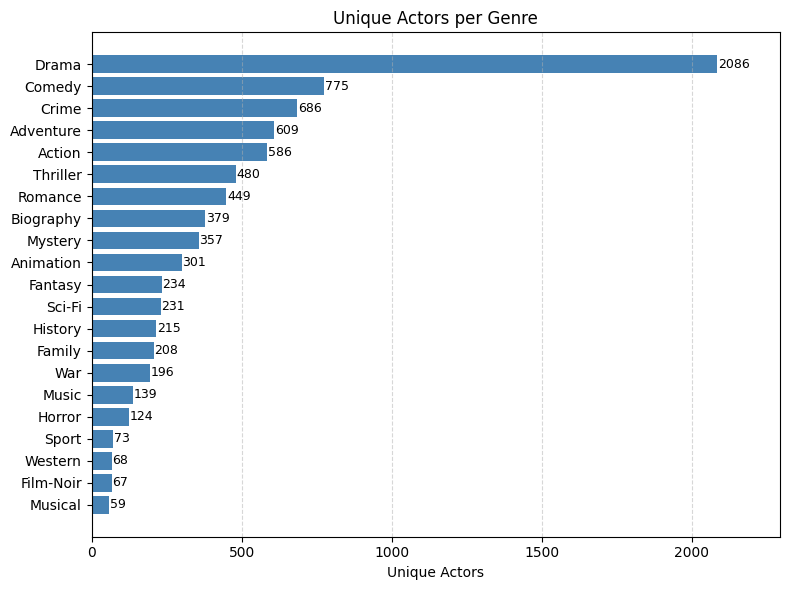

In [31]:
plot_df = genre_actor_df.sort_values('Unique_Actors', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(plot_df['Genre'], plot_df['Unique_Actors'], color='steelblue')

for bar, val in zip(bars, plot_df['Unique_Actors']):
    ax.text(
        bar.get_width() + 2,          
        bar.get_y() + bar.get_height() / 2, 
        str(val),
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Unique Actors')
ax.set_title('Unique Actors per Genre')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, plot_df['Unique_Actors'].max() * 1.1)  

plt.tight_layout()
plt.show()

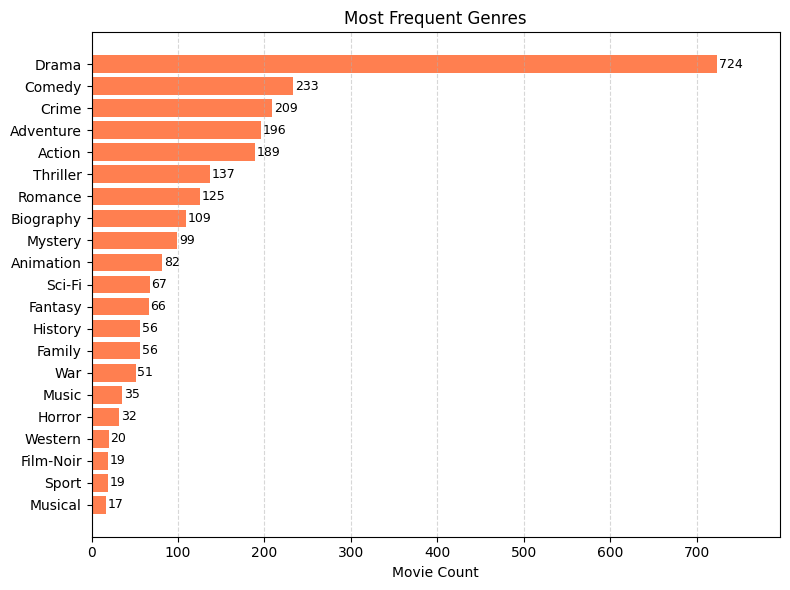

In [32]:
plot_df2 = genre_actor_df.sort_values('Movie_Count', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(plot_df2['Genre'], plot_df2['Movie_Count'], color='coral')

for bar, val in zip(bars, plot_df2['Movie_Count']):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Movie Count')
ax.set_title('Most Frequent Genres')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, plot_df2['Movie_Count'].max() * 1.1)

plt.tight_layout()
plt.show()

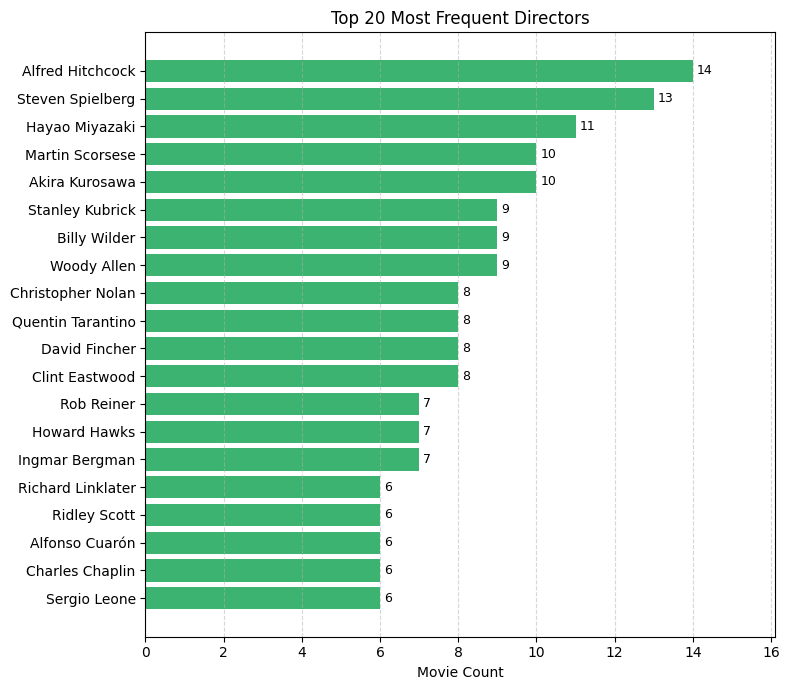

In [33]:
director_counts = df['Director'].value_counts().head(20)
plot_df3 = director_counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(plot_df3.index, plot_df3.values, color='mediumseagreen')

for bar, val in zip(bars, plot_df3.values):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Movie Count')
ax.set_title('Top 20 Most Frequent Directors')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, plot_df3.values.max() * 1.15)

plt.tight_layout()
plt.show()

# Support

In [34]:
def get_itemset_support(baskets, metadata, k=1, top_n=None, genre=None):
    """
    Parameters:
        baskets   : list of lists (each basket is [Star1, Star2, Star3, Star4])
        metadata  : list of dicts with at least a 'Genre' key (parallel to baskets)
        k         : int — itemset size (1=singleton, 2=doubleton, 3=tripleton, ...)
        top_n     : int or None — return only top N items by support
        genre     : str or None — filter to baskets where genre appears in 'Genre'
    """
    itemset_support = defaultdict(int)

    for basket, meta in zip(baskets, metadata):
        if genre is not None:
            film_genres = [g.strip() for g in meta['Genre'].split(',')]
            if genre not in film_genres:
                continue
        for itemset in combinations(sorted(basket), k):
            itemset_support[itemset] += 1

    itemset_support = dict(
        sorted(itemset_support.items(), key=lambda x: x[1], reverse=True)
    )

    if top_n is not None:
        itemset_support = dict(list(itemset_support.items())[:top_n])

    return itemset_support



In [35]:
top_n = 5
genre = None
metadata = df[['Genre']].to_dict(orient='records')

singleton_support  = get_itemset_support(baskets, metadata, k=1, top_n=top_n, genre=genre)
doubleton_support  = get_itemset_support(baskets, metadata, k=2, top_n=top_n, genre=genre)
tripleton_support  = get_itemset_support(baskets, metadata, k=3, top_n=top_n, genre=genre)

for label, result in [("Singleton", singleton_support),
                      ("Doubleton", doubleton_support),
                      ("Tripleton", tripleton_support)]:
    print(f"\n{label} Support (genre={'All' if genre is None else genre}, top_n={top_n}):")
    for itemset, sup in result.items():
        print(f"  {itemset}: {sup}")


Singleton Support (genre=All, top_n=5):
  ('Robert De Niro',): 17
  ('Tom Hanks',): 14
  ('Al Pacino',): 13
  ('Brad Pitt',): 12
  ('Clint Eastwood',): 12

Doubleton Support (genre=All, top_n=5):
  ('Daniel Radcliffe', 'Rupert Grint'): 6
  ('Daniel Radcliffe', 'Emma Watson'): 5
  ('Emma Watson', 'Rupert Grint'): 5
  ('Joe Pesci', 'Robert De Niro'): 4
  ('Tim Allen', 'Tom Hanks'): 4

Tripleton Support (genre=All, top_n=5):
  ('Daniel Radcliffe', 'Emma Watson', 'Rupert Grint'): 5
  ('Carrie Fisher', 'Harrison Ford', 'Mark Hamill'): 3
  ('Elijah Wood', 'Ian Mckellen', 'Orlando Bloom'): 3
  ('Ian Mckellen', 'Martin Freeman', 'Richard Armitage'): 2
  ('Chico Marx', 'Groucho Marx', 'Harpo Marx'): 2


# Confidence 

In [36]:
confidence({"Christian Bale"}, {"Robert De Niro"}, baskets, verbose=True)


  support({'Christian Bale'})          = 11
  support({'Robert De Niro', 'Christian Bale'})    = 0
  confidence({'Christian Bale'} → {'Robert De Niro'}) = 0/11 = 0.0000


0.0

Interpretation : Christian Bale appears in 11 different movies. But Robert De Niro does not appear in any movie that Christian Bale appeared. Therefore, Confidence score is 0/11 = 0

In [37]:
confidence({"Emma Watson"}, {"Rupert Grint"}, baskets, verbose=True)


  support({'Emma Watson'})          = 7
  support({'Emma Watson', 'Rupert Grint'})    = 5
  confidence({'Emma Watson'} → {'Rupert Grint'}) = 5/7 = 0.7143


0.7142857142857143

Interpretation : Emma Watson appears in 7 diferent movies. Rubert Grint appears in 5 movies among those 7 movies that Emma Watson appeared in. Therefore, confidence level is 5/7 = 0.71

In [38]:
confidence({"Orlando Bloom"}, {"Elijah Wood"}, baskets, verbose=True)


  support({'Orlando Bloom'})          = 4
  support({'Elijah Wood', 'Orlando Bloom'})    = 3
  confidence({'Orlando Bloom'} → {'Elijah Wood'}) = 3/4 = 0.7500


0.75

Interpretation : Orlando Bloom appears in 4 movies. Elija Wood appears in 3 movies among those 4 movies that Orlando Bloom appeared in.Therefore, confidence level is 3/4 = 0.75

# Interest

In [39]:
interest({"Orlando Bloom"}, {"Elijah Wood"}, baskets, verbose=True)

  support({'Orlando Bloom'})          = 4
  support({'Elijah Wood', 'Orlando Bloom'})    = 3
  confidence({'Orlando Bloom'} → {'Elijah Wood'}) = 3/4 = 0.7500
  P({'Elijah Wood'})= 3/1000 = 0.0030
  interest({'Orlando Bloom'} → {'Elijah Wood'}) = 0.7500 - 0.0030 = 0.7470


0.747

Confidence level is 0.75 for Orlando Bloom -> Elijah Wood.

Elija Wood appears in 3 movies among all 1000 movies in dataset -> 3/1000 = 0.003

Therefore, interest level is ;

0.75 - 0.003 = 0.747

So, presence of Orlando Bloom encourages Elijah Wood to be in that movie.

# Pair Counting Data Structures

In [40]:
def triangular_matrix_method(baskets, item_filter=None):
    all_items = sorted({
        item for basket in baskets for item in basket
        if item_filter is None or item in item_filter
    })
    item_to_idx = {item: i+1 for i, item in enumerate(all_items)}
    n = len(all_items)

    size = n * (n - 1) // 2
    a = [0] * (size + 1)

    def get_index(i, j):
        if i > j:
            i, j = j, i
        return (i - 1) * n - i * (i - 1) // 2 + (j - i)

    for basket in baskets:
        indices = sorted([
            item_to_idx[item] for item in basket
            if item_filter is None or item in item_filter
        ])
        for i, j in combinations(indices, 2):
            k = get_index(i, j)
            a[k] += 1

    result = {}
    for item_i, item_j in combinations(all_items, 2):
        i, j = item_to_idx[item_i], item_to_idx[item_j]
        k = get_index(i, j)
        if a[k] > 0:
            result[frozenset({item_i, item_j})] = a[k]

    return result


def triples_method(baskets, item_filter=None, pair_filter=None):
    triples = {}

    for basket in baskets:
        items = [item for item in basket if item_filter is None or item in item_filter]
        for item_i, item_j in combinations(sorted(items), 2):
            key = frozenset({item_i, item_j})
            if pair_filter is not None and not pair_filter(key):
                continue
            triples[key] = triples.get(key, 0) + 1

    triples = dict(sorted(triples.items(), key=lambda x: x[1], reverse=True))
    return triples

# A-Priori Algorithm

In [41]:
def apriori(baskets, support_threshold, verbose=False):

    if verbose: print("Pass 1 : Calculation occureness of items")
    singleton_counts = {}
    for basket in baskets:
        for item in basket:
            singleton_counts[item] = singleton_counts.get(item, 0) + 1

    if verbose: print('Occureness of Items:', singleton_counts)

    L1 = {frozenset([item]) for item, count in singleton_counts.items() if count >= support_threshold}

    if verbose: print(f"\n=== BETWEEN PASSES: L1 (frequent singletons, support >= {support_threshold}) ===")
    if verbose: print(f"  {[set(s) for s in L1]}\n")

    if not L1:
        return {}

    frequent_itemsets = {1: L1}
    support_counts = {frozenset([item]): count for item, count in singleton_counts.items() if count >= support_threshold}

    k = 2

    while True:

        Lk_prev = frequent_itemsets[k - 1]
        Ck_counts = {}

        if k == 2:
            frequent_items_set = {item for fs in L1 for item in fs}
            Ck_counts = triples_method(baskets, item_filter=frequent_items_set)
        else:
            for basket in baskets:
                # Start with items in this basket that are frequent singletons
                frequent_in_basket = [item for item in basket if frozenset([item]) in L1]
                basket_set = set(frequent_in_basket)


                eligible = [
                    item for item in frequent_in_basket
                    if sum(
                        1 for s in Lk_prev
                        if item in s and s <= basket_set
                    ) >= 2
                ]

                for candidate in combinations(sorted(eligible), k):
                    subsets = [frozenset(candidate) - {item} for item in candidate]
                    if all(s in Lk_prev for s in subsets):
                        key = frozenset(candidate)
                        Ck_counts[key] = Ck_counts.get(key, 0) + 1

        if verbose:
            print(f"=== PASS {k}: Candidate itemsets C{k} counts ===")
            for itemset, count in sorted(Ck_counts.items(), key=lambda x: x[1], reverse=True):
                print(f"  {set(itemset)}: {count}")

        Lk = {itemset for itemset, count in Ck_counts.items() if count >= support_threshold}

        if verbose: print(f"\n=== BETWEEN PASSES: L{k} (frequent {k}-itemsets, support >= {support_threshold}) ===")
        if verbose: print(f"  {[set(s) for s in Lk]}\n")

        if not Lk:
            if verbose: print(f"  No frequent {k}-itemsets found. Stopping.")
            break

        for itemset in Lk:
            support_counts[itemset] = Ck_counts[itemset]

        frequent_itemsets[k] = Lk
        k += 1

    return generate_association_rules(support_counts, baskets)

In [42]:
apriori_results = apriori(baskets, support_threshold=SUPPORT_LEVEL)

In [43]:
apriori_results

,antecedents,consequents,support,confidence,interest
0,"{Emma Watson, Rupert Grint}",{Daniel Radcliffe},5,100.00,0.9940
1,"{Emma Watson, Daniel Radcliffe}",{Rupert Grint},5,100.00,0.9940
2,{Daniel Radcliffe},{Rupert Grint},6,100.00,0.9940
3,{Rupert Grint},{Daniel Radcliffe},6,100.00,0.9940
4,"{Rupert Grint, Daniel Radcliffe}",{Emma Watson},5,83.33,0.8263
5,{Daniel Radcliffe},{Emma Watson},5,83.33,0.8263
6,{Rupert Grint},{Emma Watson},5,83.33,0.8263
7,{Emma Watson},{Daniel Radcliffe},5,71.43,0.7083
8,{Emma Watson},{Rupert Grint},5,71.43,0.7083


# The Multihash Algorithm

In [44]:


def _default_hash_functions(num_tables: int, num_buckets: int, seed: int = 42):
    """
    hash: h(x) = (a*x + b) mod p mod B
    """

    p = (1 << 31) - 1  # 2^31 - 1

    rng = random.Random(seed)

    def make_fn(table_idx: int):
        a = rng.randint(1, p - 1)
        b = rng.randint(0, p - 1)

        def _hash(pair: frozenset) -> int:
            x, y = sorted(str(item) for item in pair)
            combined = hash((x, y))
            return ((a * combined + b) % p) % num_buckets
        return _hash

    return [make_fn(t) for t in range(num_tables)]



def multihash_algorithm(
    baskets:         list[set],
    support:         int,
    num_hash_tables: int = 2,
    num_buckets:     int | None = None,
) -> dict[frozenset, int]:

    if not baskets:
        return {}

    if num_buckets is None:
        total_pairs = sum(math.comb(len(b), 2) for b in baskets)
        num_buckets = max(11, total_pairs // max(1, support) * 2 + 1)
        if num_buckets % 2 == 0:
            num_buckets += 1

    hash_fns = _default_hash_functions(num_hash_tables, num_buckets)

    # Pass 1
    item_counts   = defaultdict(int)
    bucket_counts = [[0] * num_buckets for _ in range(num_hash_tables)]

    for basket in baskets:
        for item in basket:
            item_counts[item] += 1
        items = list(basket)
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                pair = frozenset({items[i], items[j]})
                for t, hfn in enumerate(hash_fns):
                    bucket_counts[t][hfn(pair)] += 1

    # Between passes : 1st pass <-> 2nd pass
    frequent_items   = {item for item, cnt in item_counts.items()
                        if cnt >= support}
    frequent_buckets = [
        [cnt >= support for cnt in bucket_counts[t]]
        for t in range(num_hash_tables)
    ]

    # Pass 2: count candidate pairs via triples_method
    pair_filter = lambda pair: all(
        frequent_buckets[t][hash_fns[t](pair)] for t in range(num_hash_tables)
    )
    pair_counts = triples_method(baskets, item_filter=frequent_items, pair_filter=pair_filter)

    frequent_pairs = {pair: cnt for pair, cnt in pair_counts.items()
                      if cnt >= support}

    all_frequent: dict[frozenset, int] = {}

    for item in frequent_items:
        all_frequent[frozenset({item})] = item_counts[item]

    all_frequent.update(frequent_pairs)

    # k>=3
    def generate_candidates(prev_frequent: dict[frozenset, int], k: int) -> set[frozenset]:
        candidates = set()
        prev_list  = list(prev_frequent.keys())

        for i in range(len(prev_list)):
            for j in range(i + 1, len(prev_list)):
                union = prev_list[i] | prev_list[j]
                if len(union) == k:
                    if not union <= frequent_items:
                        continue
                    if all(frozenset(sub) in prev_frequent
                           for sub in itertools.combinations(union, k - 1)):
                        candidates.add(frozenset(union))
        return candidates

    prev_frequent_dict = frequent_pairs
    k = 3

    while prev_frequent_dict:
        candidates = generate_candidates(prev_frequent_dict, k)
        if not candidates:
            break

        candidate_counts = defaultdict(int)
        for basket in baskets:
            basket_fs = frozenset(basket)
            for candidate in candidates:
                if candidate <= basket_fs:
                    candidate_counts[candidate] += 1

        new_frequent = {c: cnt for c, cnt in candidate_counts.items()
                        if cnt >= support}
        all_frequent.update(new_frequent)
        prev_frequent_dict = new_frequent
        k += 1

    return all_frequent, generate_association_rules(all_frequent, baskets)

In [45]:
_, result_mh = multihash_algorithm(baskets, support=SUPPORT_LEVEL)

In [46]:
result_mh

,antecedents,consequents,support,confidence,interest
0,"{Emma Watson, Daniel Radcliffe}",{Rupert Grint},5,100.00,0.9940
1,"{Emma Watson, Rupert Grint}",{Daniel Radcliffe},5,100.00,0.9940
2,{Daniel Radcliffe},{Rupert Grint},6,100.00,0.9940
3,{Rupert Grint},{Daniel Radcliffe},6,100.00,0.9940
4,"{Rupert Grint, Daniel Radcliffe}",{Emma Watson},5,83.33,0.8263
5,{Daniel Radcliffe},{Emma Watson},5,83.33,0.8263
6,{Rupert Grint},{Emma Watson},5,83.33,0.8263
7,{Emma Watson},{Daniel Radcliffe},5,71.43,0.7083
8,{Emma Watson},{Rupert Grint},5,71.43,0.7083


# The SON Algorithm (Using Multihash)

In [47]:

def son_algorithm(
    baskets:           list[set],
    support_threshold: int,
    num_chunks:        int = 5,
    num_hash_tables:   int = 2,
    num_buckets:       int | None = None,
) -> dict:

    n          = len(baskets)
    chunk_size = max(1, n // num_chunks)
    p          = chunk_size / n

    local_support = max(1, int(math.floor(p * support_threshold)))

    all_candidates: set[frozenset] = set()

    chunks = [
        baskets[i : i + chunk_size]
        for i in range(0, n, chunk_size)
    ]

    for chunk in chunks:
        if not chunk:
            continue
        local_frequent, _ = multihash_algorithm(
            chunk,
            support=local_support,
            num_hash_tables=num_hash_tables,
            num_buckets=num_buckets,
        )
        all_candidates |= local_frequent.keys()

    # PASS 2: count every candidate over the FULL dataset
    global_counts: dict[frozenset, int] = defaultdict(int)

    for basket in baskets:
        basket_set = frozenset(basket)
        for candidate in all_candidates:
            if candidate <= basket_set:
                global_counts[candidate] += 1

    frequent_itemsets = {
        c for c, cnt in global_counts.items()
        if cnt >= support_threshold
    }

    false_positives = all_candidates - frequent_itemsets

    return generate_association_rules(
        frequent_itemsets,
        baskets,
        global_counts=dict(global_counts),
    )

In [48]:
result_son = son_algorithm(
        baskets,
        support_threshold=SUPPORT_LEVEL,
        num_chunks=2,
        num_hash_tables=2,
    )

In [49]:
result_son

,antecedents,consequents,support,confidence,interest
0,"{Emma Watson, Daniel Radcliffe}",{Rupert Grint},5,100.00,0.9940
1,"{Emma Watson, Rupert Grint}",{Daniel Radcliffe},5,100.00,0.9940
2,{Daniel Radcliffe},{Rupert Grint},6,100.00,0.9940
3,{Rupert Grint},{Daniel Radcliffe},6,100.00,0.9940
4,"{Rupert Grint, Daniel Radcliffe}",{Emma Watson},5,83.33,0.8263
5,{Daniel Radcliffe},{Emma Watson},5,83.33,0.8263
6,{Rupert Grint},{Emma Watson},5,83.33,0.8263
7,{Emma Watson},{Daniel Radcliffe},5,71.43,0.7083
8,{Emma Watson},{Rupert Grint},5,71.43,0.7083


# The SON Algorithm Implementation with MapReduce

In [50]:

def son_mapreduce(
    baskets:           list[set],
    support_threshold: int,
    num_chunks:        int = 5,
    num_hash_tables:   int = 2,
    num_buckets:       int | None = None,
) -> dict:

    import multiprocessing

    n             = len(baskets)
    chunk_size    = max(1, n // num_chunks)
    local_support = max(1, int(math.floor((chunk_size / n) * support_threshold)))

    chunks = [
        baskets[i : i + chunk_size]
        for i in range(0, n, chunk_size)
        if baskets[i : i + chunk_size]
    ]

    ctx = multiprocessing.get_context("fork")

    def parallel_map(fn, items):
        conns, procs = [], []
        for item in items:
            recv_conn, send_conn = ctx.Pipe(duplex=False)

            def worker(conn=send_conn, x=item):
                conn.send(fn(x))
                conn.close()

            p = ctx.Process(target=worker)
            p.start()
            send_conn.close()
            conns.append(recv_conn)
            procs.append(p)

        results = [conn.recv() for conn in conns]
        for p in procs:
            p.join()
        return results

    def phase1_worker(chunk):
        local_frequent, _ = multihash_algorithm(
            chunk,
            support=local_support,
            num_hash_tables=num_hash_tables,
            num_buckets=num_buckets,
        )
        return [(itemset, 1) for itemset in local_frequent]

    def phase2_worker(chunk):
        local_counts: dict[frozenset, int] = defaultdict(int)
        for basket in chunk:
            basket_set = frozenset(basket)
            for candidate in all_candidates:
                if candidate <= basket_set:
                    local_counts[candidate] += 1
        return [(c, cnt) for c, cnt in local_counts.items() if cnt > 0]

    # MapReduce Job 1
    phase1_mapped = parallel_map(phase1_worker, chunks)

    all_candidates: set[frozenset] = {
        itemset for kv_pairs in phase1_mapped for itemset, _ in kv_pairs
    }

    # MapReduce Job 2
    phase2_mapped = parallel_map(phase2_worker, chunks)

    global_counts: dict[frozenset, int] = defaultdict(int)
    for kv_pairs in phase2_mapped:
        for candidate, count in kv_pairs:
            global_counts[candidate] += count

    frequent_itemsets = {c for c, cnt in global_counts.items() if cnt >= support_threshold}

    return generate_association_rules(
        frequent_itemsets,
        baskets,
        global_counts=dict(global_counts),
    )

In [51]:
result_son_mp = son_mapreduce(
    baskets=baskets,
    support_threshold=SUPPORT_LEVEL,
    num_chunks=2,
    num_hash_tables=2,
    num_buckets=None,
)

In [52]:
result_son_mp

,antecedents,consequents,support,confidence,interest
0,"{Emma Watson, Daniel Radcliffe}",{Rupert Grint},5,100.00,0.9940
1,"{Emma Watson, Rupert Grint}",{Daniel Radcliffe},5,100.00,0.9940
2,{Daniel Radcliffe},{Rupert Grint},6,100.00,0.9940
3,{Rupert Grint},{Daniel Radcliffe},6,100.00,0.9940
4,"{Rupert Grint, Daniel Radcliffe}",{Emma Watson},5,83.33,0.8263
5,{Daniel Radcliffe},{Emma Watson},5,83.33,0.8263
6,{Rupert Grint},{Emma Watson},5,83.33,0.8263
7,{Emma Watson},{Daniel Radcliffe},5,71.43,0.7083
8,{Emma Watson},{Rupert Grint},5,71.43,0.7083


# Algorithm Benchmark

In [53]:
def _timed(fn):
    t0 = time.perf_counter()
    result = fn()
    t1 = time.perf_counter()
    return t0, t1, result
def benchmark(
    baskets: list[set],
    sample_fractions: list[float] = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    support: int = 3,
    n_trials: int = 5,
    seed: int = 42,
) -> pd.DataFrame:
    rng = random.Random(seed)

    algorithms = {
        "apriori":       lambda b, s: apriori(b, s),
        "multihash":     lambda b, s: multihash_algorithm(b, s),
        "son":           lambda b, s: son_algorithm(b, s),
        "son_mapreduce": lambda b, s: son_mapreduce(b, s),
    }

    records = []

    for fraction in sample_fractions:
        n = max(1, int(len(baskets) * fraction))
        sample = rng.sample(baskets, n)

        for algo_name, algo_fn in algorithms.items():
            runtimes, mems = [], []

            for _ in range(n_trials):
                try:
                    mem, (t0, t1, _) = memory_usage(
                        (_timed, (lambda: algo_fn(sample, support),)),
                        retval=True,
                        interval=0.01,
                        include_children=True,
                    )
                    runtimes.append(t1 - t0)
                    mems.append(max(mem) - mem[0])
                except Exception as e:
                    runtimes, mems = None, None
                    error = str(e)
                    break

            if runtimes is None:
                records.append({
                    "algorithm": algo_name, "sample_fraction": fraction,
                    "sample_size": n, "runtime_mean_s": float("nan"),
                    "runtime_std_s": float("nan"), "peak_memory_mib": float("nan"),
                    "error": error,
                })
            else:
                records.append({
                    "algorithm":       algo_name,
                    "sample_fraction": fraction,
                    "sample_size":     n,
                    "runtime_mean_s":  round(statistics.mean(runtimes), 4),
                    "runtime_std_s":   round(statistics.stdev(runtimes) if n_trials > 1 else 0.0, 4),
                    "peak_memory_mib": round(max(mems), 3),
                })

    return (
        pd.DataFrame(records)
        .sort_values(["sample_fraction", "algorithm"])
        .reset_index(drop=True)
    )

In [54]:
def plot_benchmark(df: pd.DataFrame) -> None:
    algorithms = df["algorithm"].unique()

    colors  = {"apriori": "#378ADD", "multihash": "#1D9E75", "son": "#D85A30", "son_mapreduce": "#9B59B6"}
    markers = {"apriori": "o",       "multihash": "s",       "son": "^",       "son_mapreduce": "*"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#FAFAFA")

    def style_ax(ax, title, ylabel):
        ax.set_facecolor("#FAFAFA")
        ax.set_title(title, fontsize=13, fontweight="500", pad=12, color="#2C2C2A")
        ax.set_xlabel("Dataset size (baskets)", fontsize=11, color="#5F5E5A")
        ax.set_ylabel(ylabel, fontsize=11, color="#5F5E5A")
        ax.tick_params(colors="#888780", labelsize=10)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.3g}"))
        for spine in ax.spines.values():
            spine.set_edgecolor("#D3D1C7")
            spine.set_linewidth(0.8)
        ax.grid(axis="y", color="#D3D1C7", linewidth=0.6, linestyle="--", alpha=0.7)
        ax.grid(axis="x", color="#D3D1C7", linewidth=0.4, linestyle=":",  alpha=0.5)
        ax.set_axisbelow(True)
        ax.legend(frameon=True, framealpha=0.9, edgecolor="#D3D1C7", fontsize=10).get_frame().set_linewidth(0.6)

    for algo in algorithms:
        subset = df[df["algorithm"] == algo].sort_values("sample_size")
        kw = dict(label=algo, color=colors.get(algo, "#888"), marker=markers.get(algo, "o"),
                  linewidth=2, markersize=6, markeredgewidth=1.5, markeredgecolor="white")

        axes[0].plot(subset["sample_size"], subset["runtime_mean_s"], **kw)
        axes[0].fill_between(subset["sample_size"],
                             subset["runtime_mean_s"] - subset["runtime_std_s"],
                             subset["runtime_mean_s"] + subset["runtime_std_s"],
                             color=colors.get(algo, "#888"), alpha=0.12)

        axes[1].plot(subset["sample_size"], subset["peak_memory_mib"], **kw)

    style_ax(axes[0], "Runtime vs dataset size", "Runtime (s)")
    style_ax(axes[1], "Memory vs dataset size",  "Peak memory (MiB)")

    plt.tight_layout(pad=2.0)
    plt.show()

In [55]:
algorithm_evaluation = benchmark(baskets)

In [56]:
algorithm_evaluation

,algorithm,sample_fraction,sample_size,runtime_mean_s,runtime_std_s,peak_memory_mib
0,apriori,0.1,100,0.0022,0.0004,0.000
1,multihash,0.1,100,0.0040,0.0019,0.203
2,son,0.1,100,0.0665,0.0004,53.125
3,son_mapreduce,0.1,100,0.0516,0.0034,147.469
4,apriori,0.2,200,0.0022,0.0002,0.203
5,multihash,0.2,200,0.0052,0.0007,0.312
6,son,0.2,200,0.2334,0.0321,137.734
7,son_mapreduce,0.2,200,0.1567,0.0893,161.484
8,apriori,0.4,400,0.0032,0.0002,0.062
9,multihash,0.4,400,0.0077,0.0002,0.000


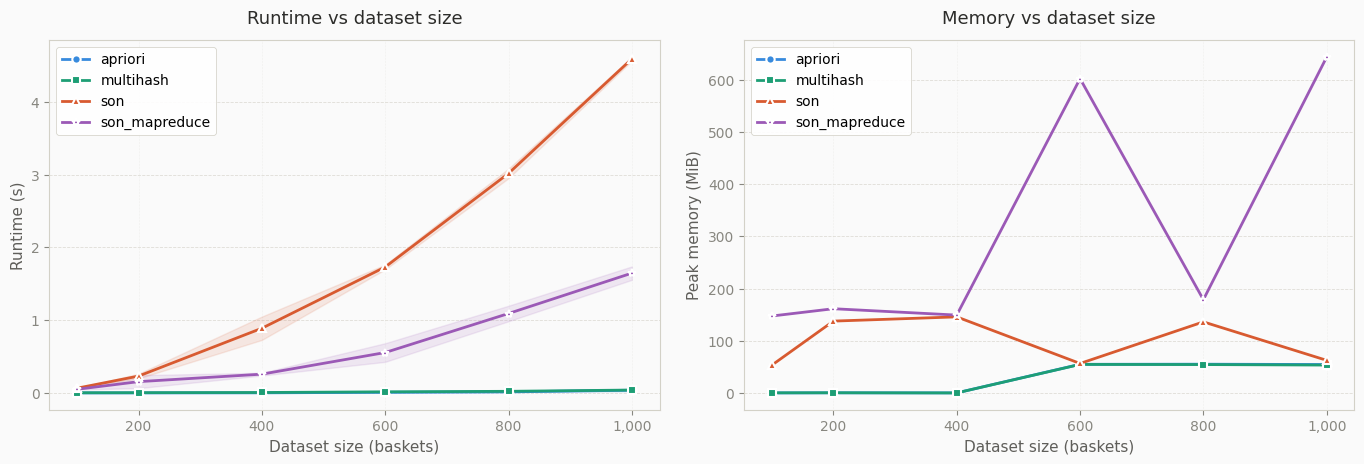

In [57]:
plot_benchmark(algorithm_evaluation)
